Students DataFrame:
   ID           Name  Age Gender    Major  Year                      Interests
0   1        Jenalyn   22      F  MSSP+DA     1  Sociology, Data Visualization
1   2      Yilei Lyu   25      F  MSSP+DA     1                             AI
2   3       Kelin Li   22      F  MSSP+DA     1                             AI
3   4      Zhouqi Pu   22      M  MSSP+DA     1                             AI
4   5   Siyuan Zheng   22      M  MSSP+DA     1                Econ & Business
5   6  Zisheng Liang   23      M  MSSP+DA     1                Econ & Business

Connections DataFrame:
    Student1  Student2 Connection Type
0          1         2       Classmate
1          1         3       Classmate
2          1         4       Classmate
3          1         5       Classmate
4          1         6       Classmate
5          2         3       Classmate
6          2         4       Classmate
7          2         5       Classmate
8          2         6       Classmate
9          3 

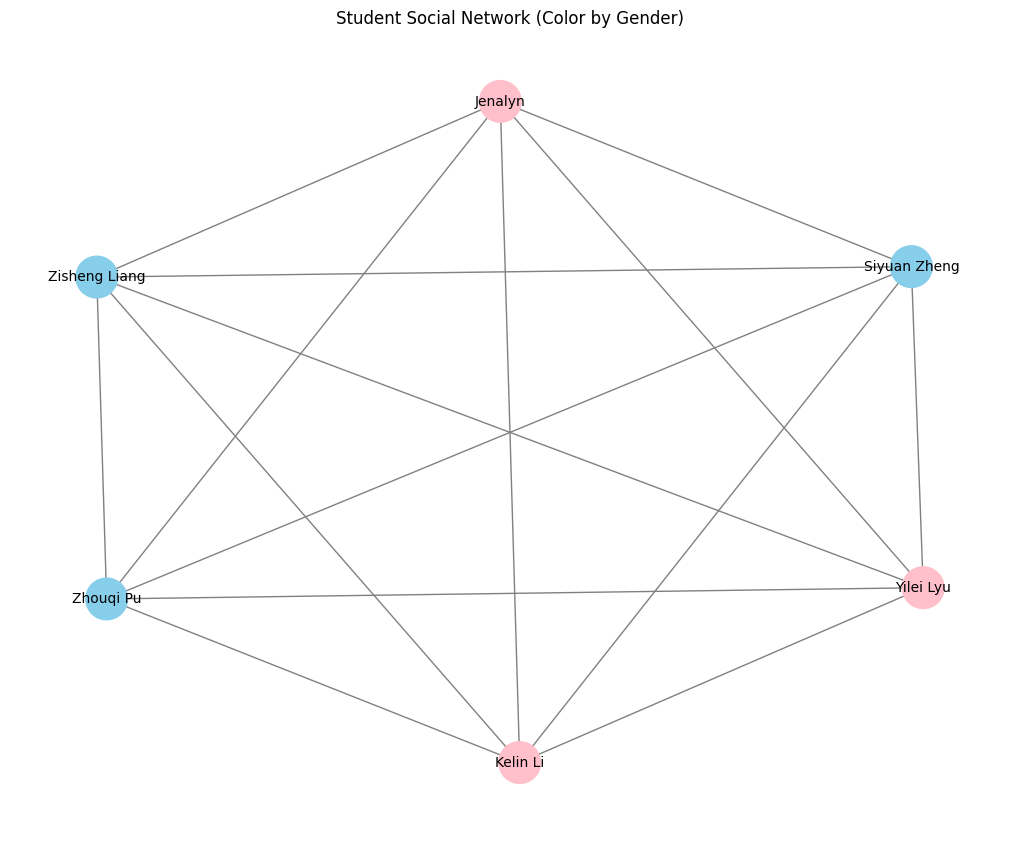

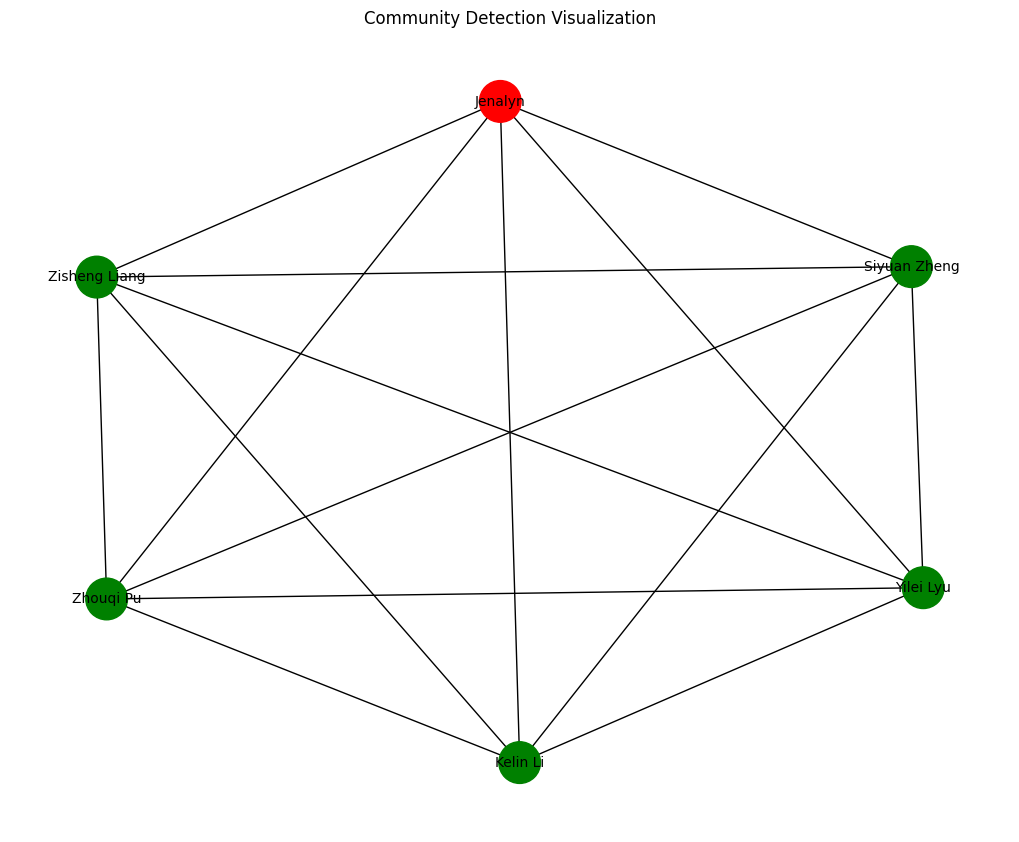

In [2]:
# =====================================================
# 0. Install packages
# =====================================================
!pip install networkx matplotlib pandas

# =====================================================
# 1. Import libraries
# =====================================================
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# 2. Manually define student data
# =====================================================

students_data = [
    {"ID": 1, "Name": "Jenalyn",       "Age": 22, "Gender": "F", "Major": "MSSP+DA", "Year": 1, "Interests": "Sociology, Data Visualization"},
    {"ID": 2, "Name": "Yilei Lyu",     "Age": 25, "Gender": "F", "Major": "MSSP+DA", "Year": 1, "Interests": "AI"},
    {"ID": 3, "Name": "Kelin Li",      "Age": 22, "Gender": "F", "Major": "MSSP+DA", "Year": 1, "Interests": "AI"},
    {"ID": 4, "Name": "Zhouqi Pu",     "Age": 22, "Gender": "M", "Major": "MSSP+DA", "Year": 1, "Interests": "AI"},
    {"ID": 5, "Name": "Siyuan Zheng",  "Age": 22, "Gender": "M", "Major": "MSSP+DA", "Year": 1, "Interests": "Econ & Business"},
    {"ID": 6, "Name": "Zisheng Liang", "Age": 23, "Gender": "M", "Major": "MSSP+DA", "Year": 1, "Interests": "Econ & Business"},
]

students = pd.DataFrame(students_data)
print("Students DataFrame:")
print(students)


# =====================================================
# 3. Define connections manually
# All classmates: every pair connected
# =====================================================
connections_data = []
for i in range(1, 7):
    for j in range(i+1, 7):
        connections_data.append({"Student1": i, "Student2": j, "Connection Type": "Classmate"})

connections = pd.DataFrame(connections_data)
print("\nConnections DataFrame:")
print(connections)


# =====================================================
# 4. Create NetworkX graph
# =====================================================
G = nx.Graph()

# Add nodes
for index, row in students.iterrows():
    G.add_node(
        row["ID"],
        name=row["Name"],
        age=row["Age"],
        gender=row["Gender"],
        major=row["Major"],
        year=row["Year"],
        interests=row["Interests"]
    )

# Add edges
for index, row in connections.iterrows():
    G.add_edge(row["Student1"], row["Student2"], connection=row["Connection Type"])

print("\nGraph Info:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Nodes and attributes:")
for n, d in G.nodes(data=True):
    print(n, d)
print("Edges and attributes:")
for u, v, d in G.edges(data=True):
    print(u, v, d)



# =====================================================
# 5. Network Analysis
# =====================================================

# ---- Degree Centrality ----
degree_centrality = nx.degree_centrality(G)
print("\nDegree Centrality:")
print(degree_centrality)

max_degree = max(degree_centrality.values())
most_connected = [k for k, v in degree_centrality.items() if v == max_degree]
print("Most connected student(s):", most_connected)

# ---- Clustering Coefficient ----
clustering = nx.clustering(G)
print("\nClustering Coefficient:")
print(clustering)

# ---- Shortest Path ----
print("\nShortest Path Lengths:")
all_paths = dict(nx.all_pairs_shortest_path_length(G))

max_distance = 0
furthest_pair = None

for i in all_paths:
    for j, dist in all_paths[i].items():
        if dist > max_distance:
            max_distance = dist
            furthest_pair = (i, j)

print(f"Furthest apart students: {furthest_pair} with distance = {max_distance}")

# ---- Community Detection (Girvan-Newman) ----
from networkx.algorithms.community import girvan_newman
communities = next(girvan_newman(G))
communities_list = [list(c) for c in communities]

print("\nCommunities Detected:")
print(communities_list)


# =====================================================
# 6. Visualization
# =====================================================

# ---- Plot: Gender color ----
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

gender_color_map = {"M": "skyblue", "F": "pink"}
node_colors = [gender_color_map[G.nodes[n]["gender"]] for n in G.nodes()]

nx.draw(
    G, pos,
    with_labels=True,
    labels={n: G.nodes[n]["name"] for n in G.nodes()},
    node_color=node_colors,
    node_size=900,
    edge_color="gray",
    font_size=10
)

plt.title("Student Social Network (Color by Gender)")
plt.show()

# ---- Plot: Communities ----
plt.figure(figsize=(10, 8))

community_colors = ["red", "green", "blue", "orange"]
community_map = {}

for idx, community in enumerate(communities_list):
    for node in community:
        community_map[node] = community_colors[idx % len(community_colors)]

node_colors2 = [community_map[n] for n in G.nodes()]

nx.draw(
    G, pos,
    with_labels=True,
    labels={n: G.nodes[n]["name"] for n in G.nodes()},
    node_color=node_colors2,
    node_size=900,
    edge_color="black",
    font_size=10
)

plt.title("Community Detection Visualization")
plt.show()
